# setup and model loading

In [1]:
# importing libraries
import io
import os
import urllib
import tarfile

import torch
import torchvision.transforms.functional as TF
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from scipy import signal
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression

In [2]:
import os
import torch

# 1. DINOv3のソースコードが置かれているディレクトリを指定
# ここに 'hubconf.py' が存在する必要があります
DINOV3_REPO_DIR = '/home/daiv02/repos/python/replicas/dinov3/model/dinov3/'

# もしディレクトリがない、または hubconf.py がない場合は clone が必要です
if not os.path.exists(os.path.join(DINOV3_REPO_DIR, 'hubconf.py')):
    print(f"Error: {DINOV3_REPO_DIR} に hubconf.py が見つかりません。")
    print("git clone https://github.com/facebookresearch/dinov3.git を実行してコードを入手してください。")

# 2. モデル構造のロード
MODEL_NAME = 'dinov3_vitl16'

model = torch.hub.load(
    repo_or_dir=DINOV3_REPO_DIR,  # 絶対パスを指定
    model=MODEL_NAME,
    source='local',
    pretrained=False,
    trust_repo=True
)

# 3. 手元にある重みファイルのロード
# ※注意：モデル名(vits16)と重みファイル(vitl16)が食い違っていないか確認してください
weights_path = '../model/facebookresearch_model/dinov3/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth'
state_dict = torch.load(weights_path, map_location='cpu')

# DINOv3の重みファイルは通常 'model' キーの中に state_dict が入っています
if 'model' in state_dict:
    model.load_state_dict(state_dict['model'])
else:
    model.load_state_dict(state_dict)

model.to('cuda')
model.eval()
print("モデルと重みの読み込みに成功しました。")

モデルと重みの読み込みに成功しました。


In [3]:
model

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm)

# dataset

In [4]:
IMAGES_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_images.tar.gz"
LABELS_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_labels.tar.gz"

def load_images_from_remote_tar(tar_uri: str) -> list[Image.Image]:
    images = []
    with urllib.request.urlopen(tar_uri) as f:
        tar = tarfile.open(fileobj=io.BytesIO(f.read()))
        for member in tar.getmembers():
            image_data = tar.extractfile(member)
            image = Image.open(image_data)
            images.append(image)
    return images
    
images = load_images_from_remote_tar(IMAGES_URI)
labels = load_images_from_remote_tar(LABELS_URI)
n_images = len(images)
assert n_images == len(labels), f"{len(images)=}, {len(labels)=}"

print(f"Loaded {n_images} images and labels")

Loaded 9 images and labels


showing image / mask at index 0


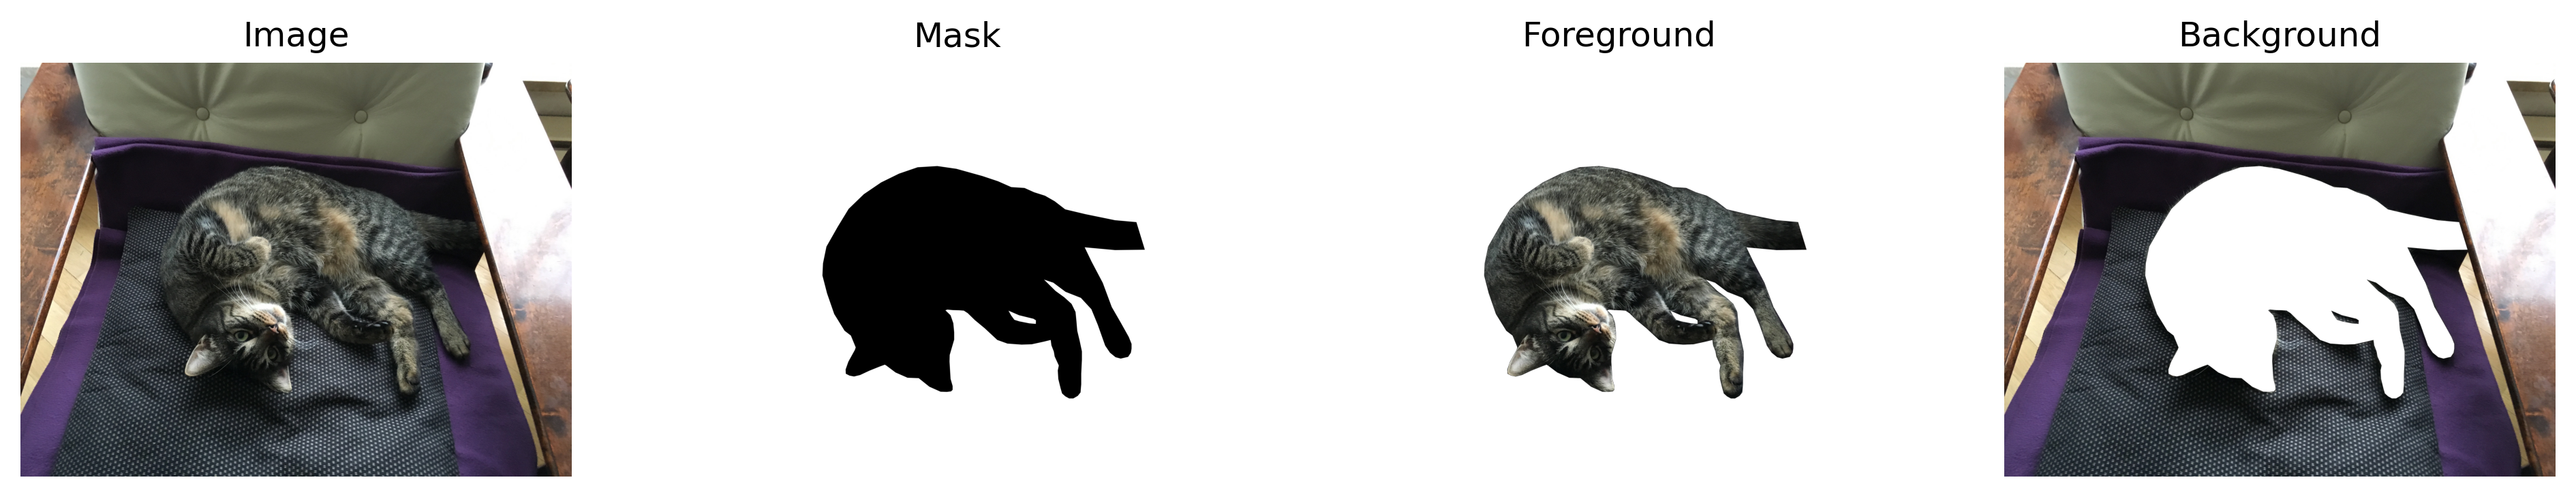

In [5]:
data_index = 0

print(f'showing image / mask at index {data_index}')

image = images[data_index]
mask = labels[data_index]
foreground = Image.composite(image, mask, mask)
mask_bg_np = np.copy(np.asarray(mask))
mask_bg_np[:, :, 3] = 255 - mask_bg_np[:, :, 3]
mask_bg = Image.fromarray(mask_bg_np)
background = Image.composite(image, mask_bg, mask_bg)

data_to_show = [image, mask, foreground, background]
data_labels = ['Image', 'Mask', 'Foreground', 'Background']

plt.figure(figsize=(16, 4), dpi=300)
for i in range(len(data_to_show)):
    plt.subplot(1, len(data_to_show), i+1)
    plt.imshow(data_to_show[i])
    plt.axis('off')
    plt.title(data_labels[i], fontsize=12)
plt.show()

# building per-patch label map

In [6]:
PATCH_SIZE = 16 # pixel
IMAGE_SIZE = 768 # pixel

# quantization filter for the given patch size
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image, 
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE
) -> torch.Tensor:
    w, h = mask_image.size
    print(f'mask image w: {w}, h: {h}')
    num_h_patches = int(image_size / patch_size) # 48
    num_w_patches = int((w * image_size ) / (h * patch_size)) # 64
    print(f'num of patch h: {num_h_patches}, w: {num_w_patches}')
    return TF.to_tensor(TF.resize(mask_image, (num_h_patches * patch_size, num_w_patches * patch_size)))

In [7]:
mask_0_rgba = labels[0].split() # split RGBA
mask_0 = mask_0_rgba[-1] # extract Alpha channel

In [8]:
mask_0_resized = resize_transform(mask_0) # resize mask

mask image w: 4032, h: 3024
num of patch h: 48, w: 64


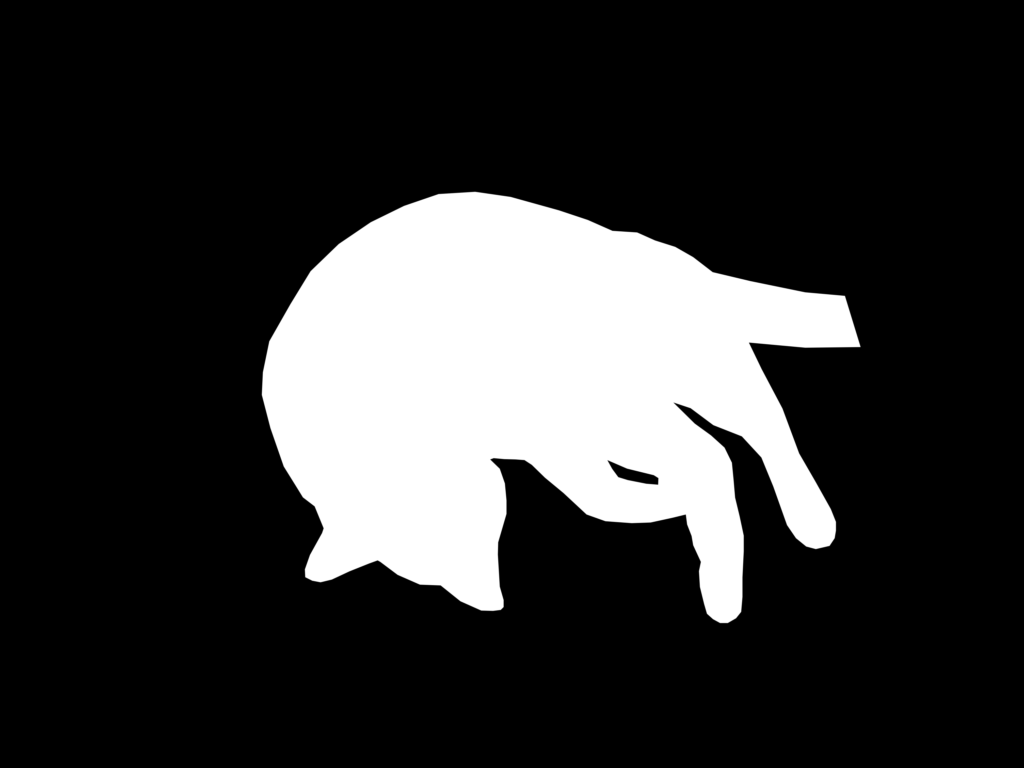

In [9]:
TF.to_pil_image(mask_0_resized)

In [10]:
with torch.no_grad():
    mask_0_quantized = patch_quant_filter(mask_0_resized).squeeze().detach().cpu()
    TF.to_pil_image(mask_0_quantized).show()

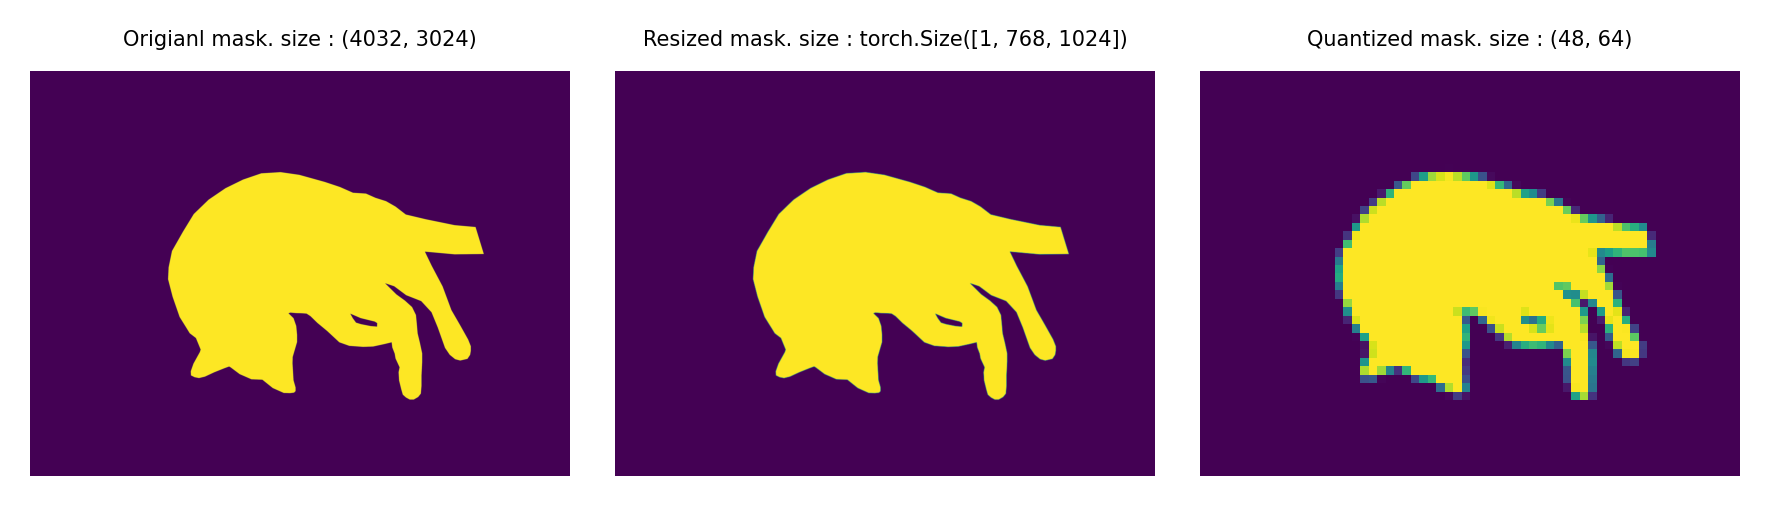

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(6, 2), dpi=300)
axes[0].imshow(mask_0)
axes[0].set_title(f'Origianl mask. size : {mask_0.size}', fontsize=5)
axes[0].axis('off')

axes[1].imshow(TF.to_pil_image(mask_0_resized))
axes[1].set_title(f'Resized mask. size : {mask_0_resized.shape}', fontsize=5)
axes[1].axis('off')

axes[2].imshow(mask_0_quantized)
axes[2].set_title(f'Quantized mask. size : {tuple(mask_0_quantized.shape)}', fontsize=5)
axes[2].axis('off')

plt.tight_layout()
plt.show()

mask image w: 4032, h: 3024
num of patch h: 48, w: 64


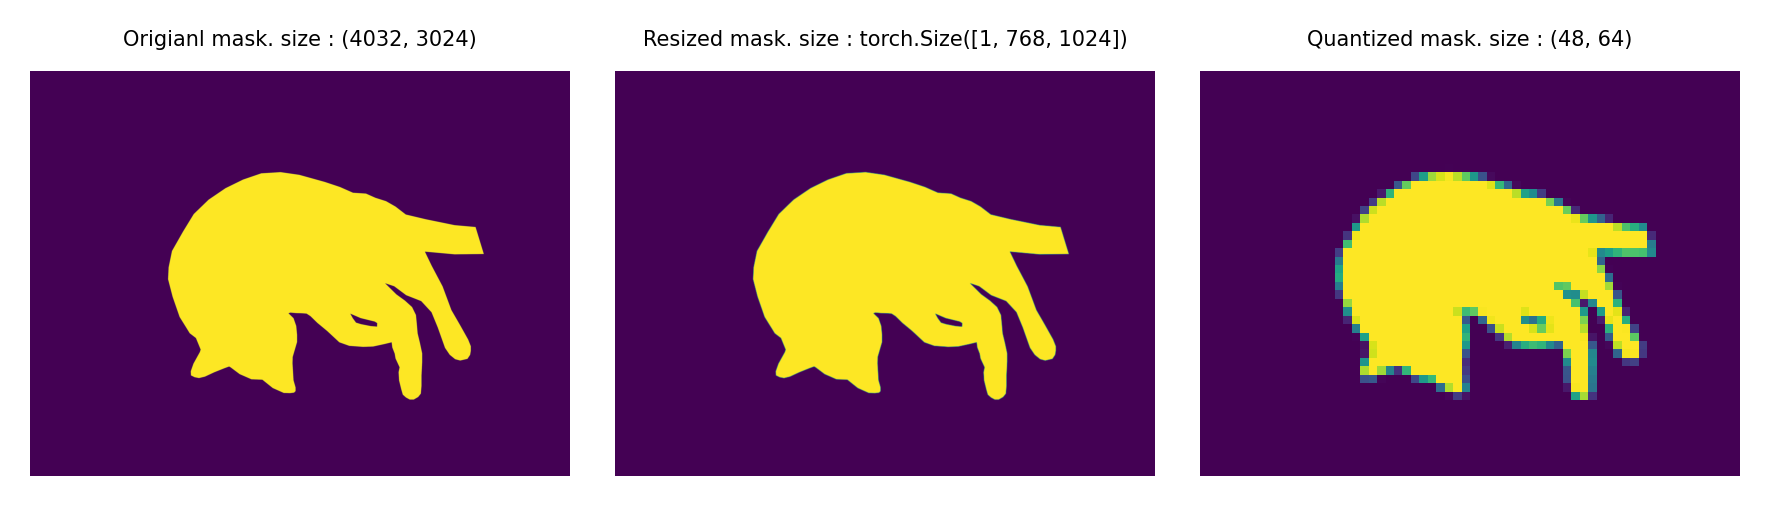

mask image w: 3024, h: 4032
num of patch h: 48, w: 36



(eog:16217): EOG-WARNING **: 15:22:18.314: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:18.355: Thumbnail creation failed


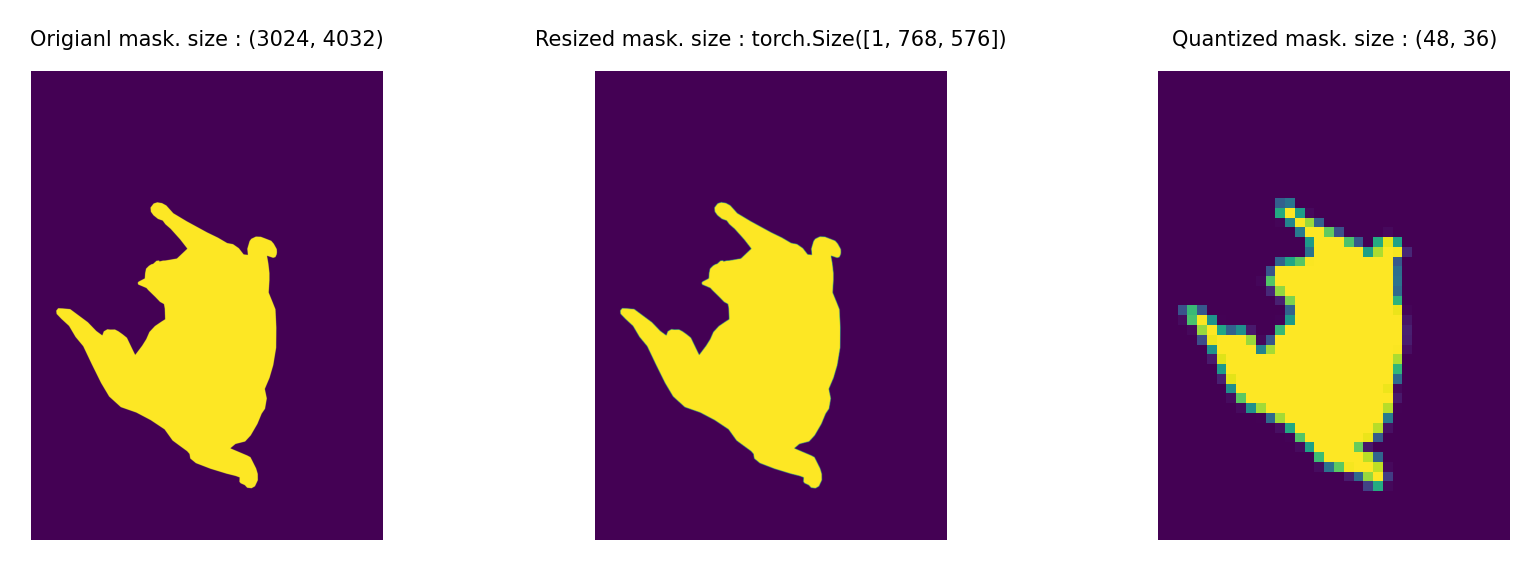

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:19.046: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:19.047: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:19.086: Thumbnail creation failed


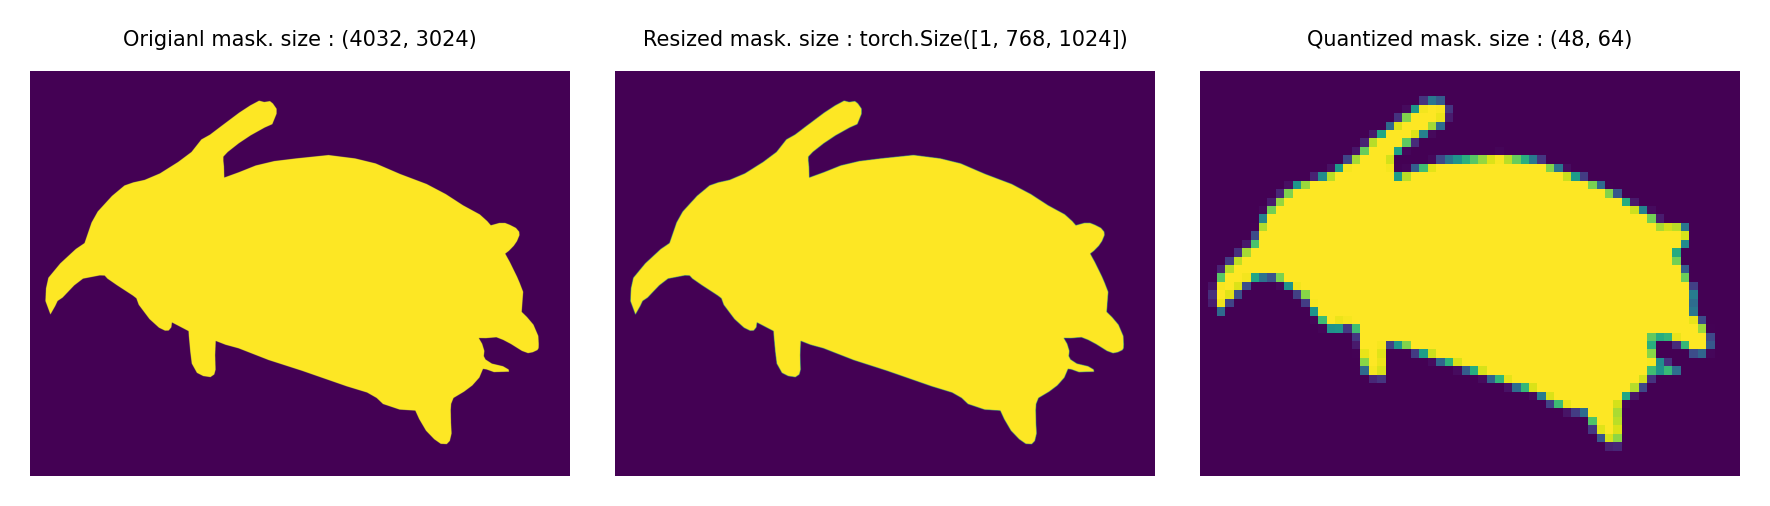

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:19.817: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:19.817: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:19.817: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:19.856: Thumbnail creation failed


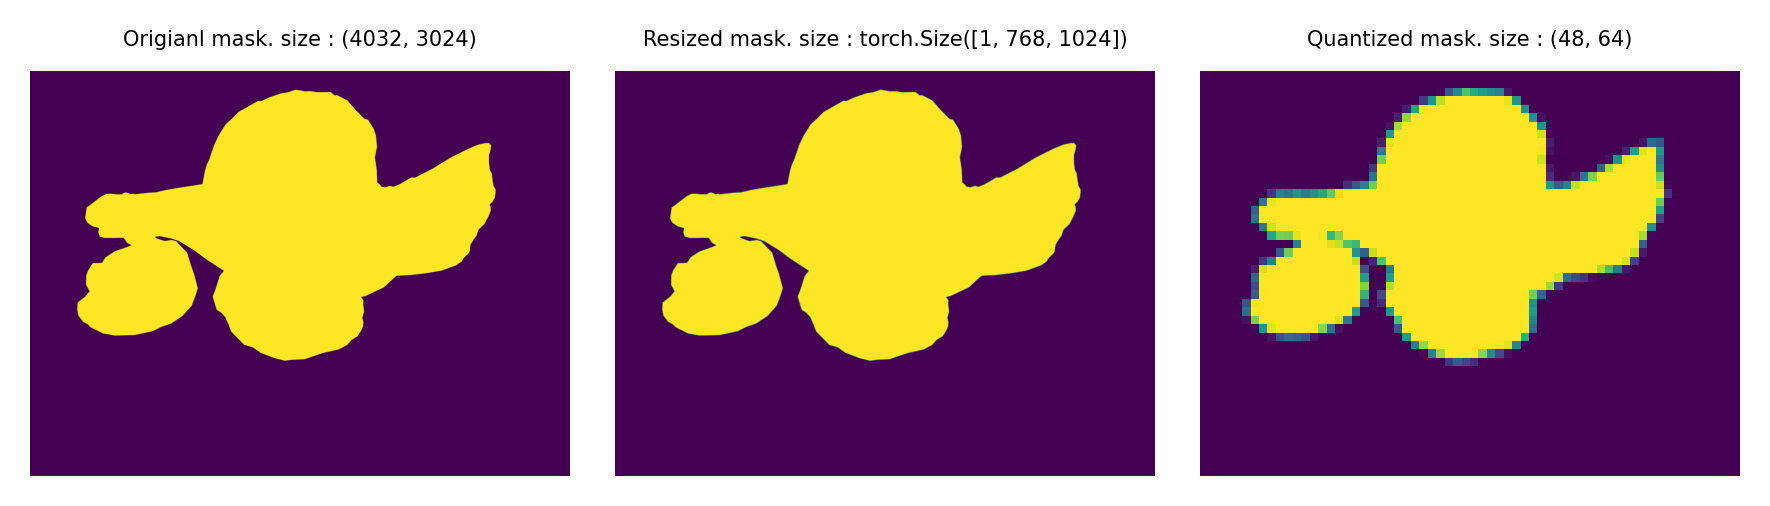

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:20.562: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:20.562: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:20.562: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:20.562: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:20.609: Thumbnail creation failed


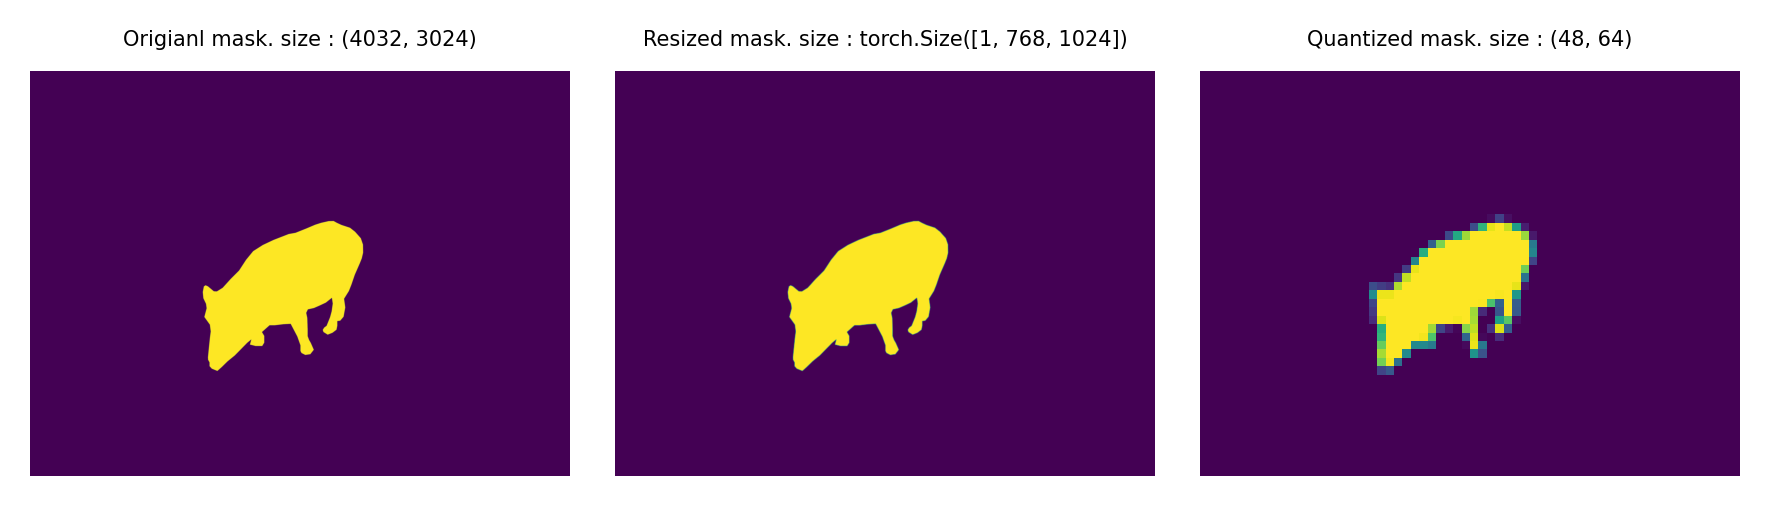

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:21.311: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:21.312: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:21.312: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:21.312: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:21.352: Thumbnail creation failed


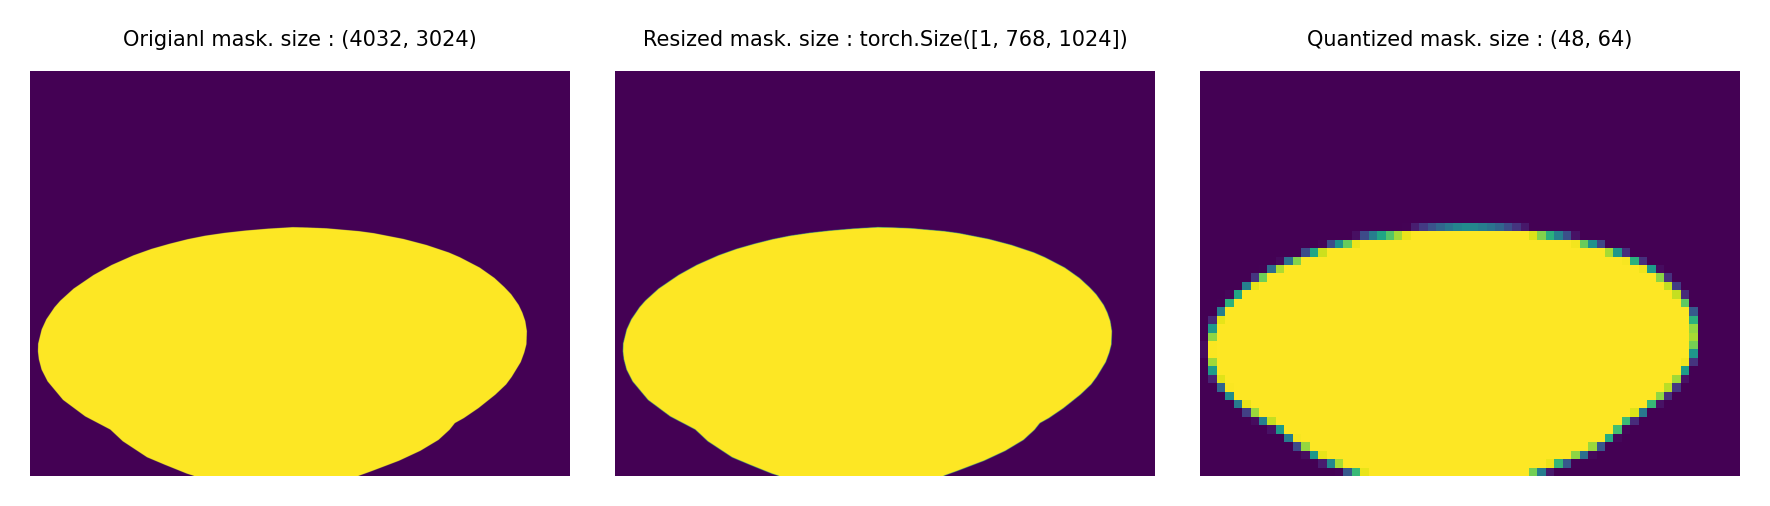

mask image w: 3024, h: 4032
num of patch h: 48, w: 36



(eog:16217): EOG-WARNING **: 15:22:22.092: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:22.092: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.092: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.092: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.092: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.133: Thumbnail creation failed


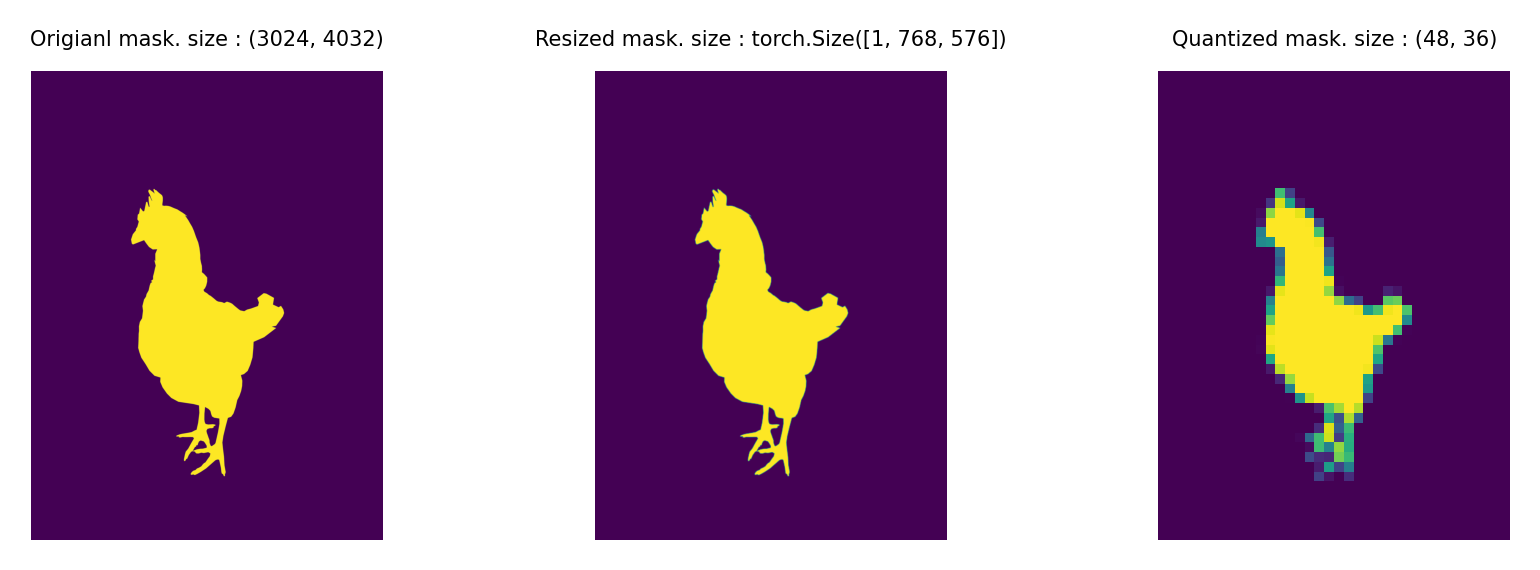

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:22.836: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:22.837: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.837: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.837: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.837: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.837: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:22.886: Thumbnail creation failed


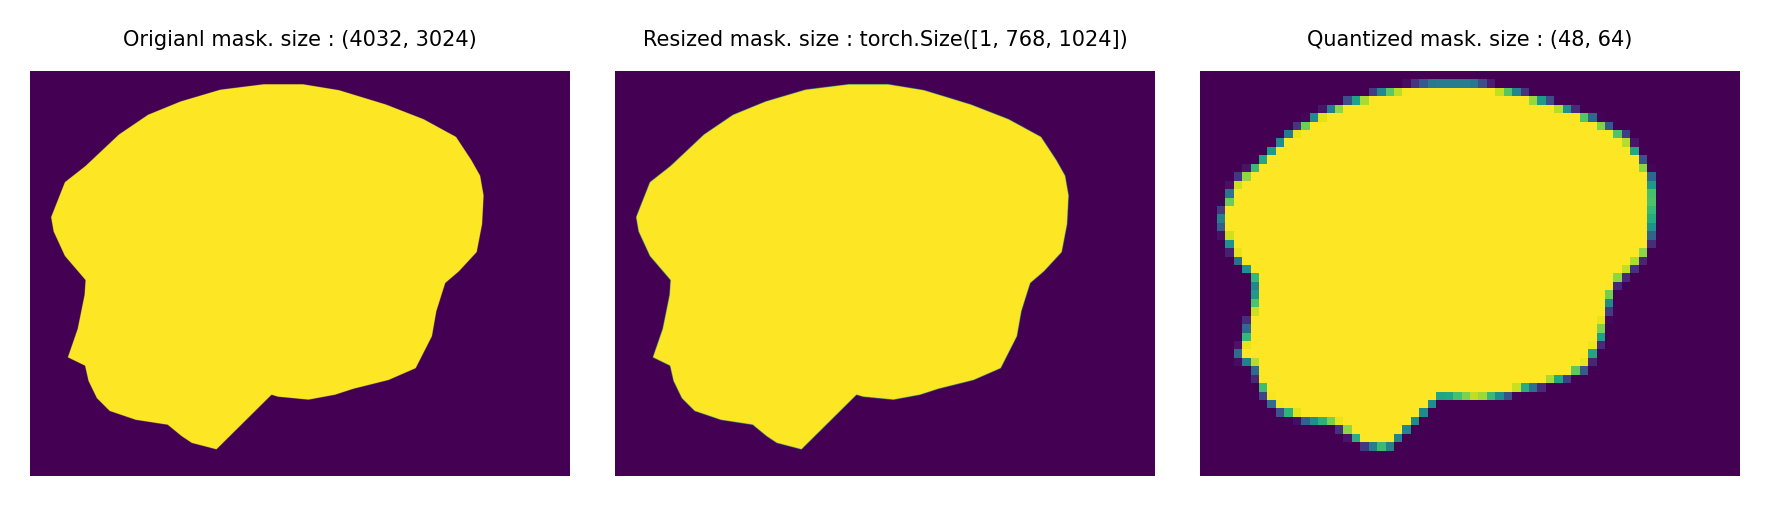

mask image w: 4032, h: 3024
num of patch h: 48, w: 64



(eog:16217): EOG-WARNING **: 15:22:23.613: Generating thumbnail failed: Child process exited with code 1

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.614: Thumbnail creation failed

(eog:16217): EOG-WARNING **: 15:22:23.653: Thumbnail creation failed


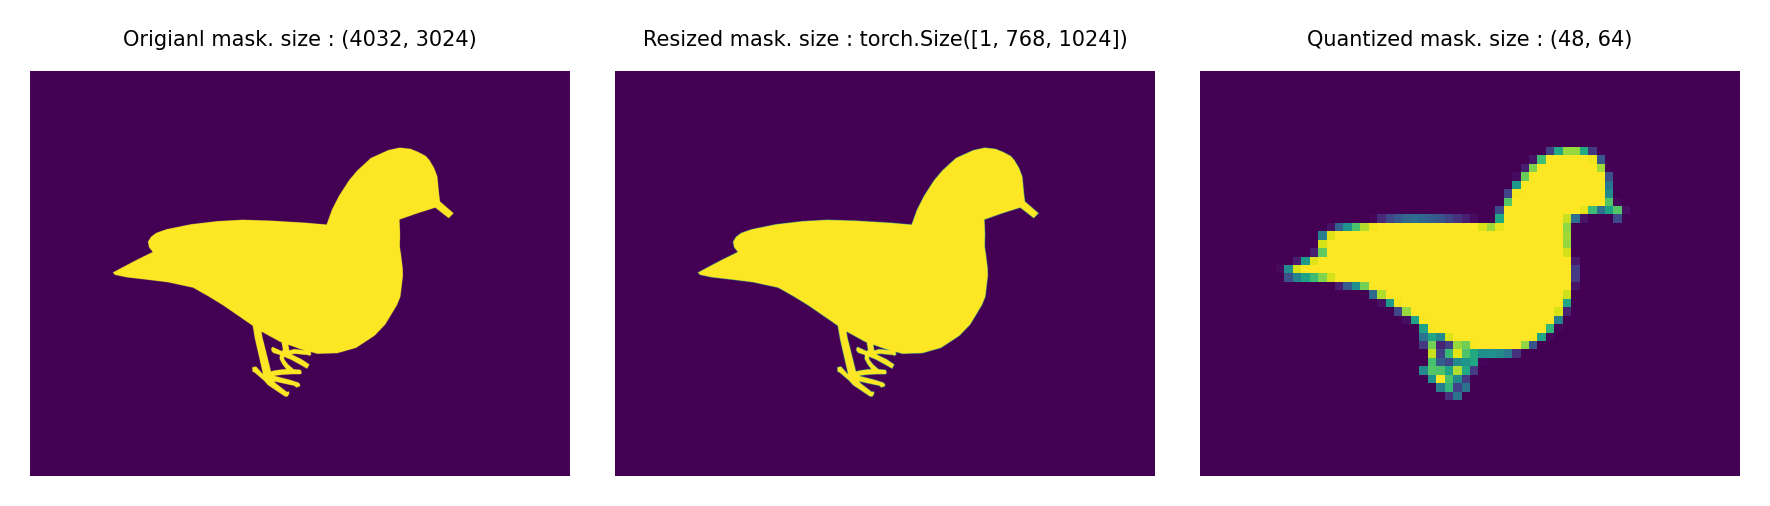

In [83]:
for i in range(len(images)):
    mask_0_rgba = labels[i].split() # split RGBA
    mask_0 = mask_0_rgba[-1] # extract Alpha channel
    mask_0_resized = resize_transform(mask_0) # resize mask

    fig, axes = plt.subplots(1, 3, figsize=(6, 2), dpi=300)
    axes[0].imshow(mask_0)
    axes[0].set_title(f'Origianl mask. size : {mask_0.size}', fontsize=5)
    axes[0].axis('off')
    
    axes[1].imshow(TF.to_pil_image(mask_0_resized))
    axes[1].set_title(f'Resized mask. size : {mask_0_resized.shape}', fontsize=5)
    axes[1].axis('off')

    with torch.no_grad():
        mask_0_quantized = patch_quant_filter(mask_0_resized).squeeze().detach().cpu()
        TF.to_pil_image(mask_0_quantized).show()
    
    axes[2].imshow(mask_0_quantized)
    axes[2].set_title(f'Quantized mask. size : {tuple(mask_0_quantized.shape)}', fontsize=5)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Extracting features and labels for all the images

In [12]:
xs = []
ys = []
image_index = []

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

n_layers = 24 # vitl16 model

In [13]:
with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        for i in tqdm(range(n_images), desc='Processing images'):
            # Load the ground truth
            mask_i = labels[i].split()[-1] # split alpha channel (alpha == mask channel)
            mask_i_reseized = resize_transform(mask_i) # resize
            mask_i_quantized = patch_quant_filter(mask_i_reseized).squeeze().view(-1).detach().cpu() # transform 1 dim vector
            print(f'{i} shape of mask_i_quantized : {mask_i_quantized.shape}')
            ys.append(mask_i_quantized)
            
            # Load the iamge data
            image_i = images[i].convert('RGB')
            image_i_resized = resize_transform(image_i)
            image_i_resized = TF.normalize(image_i_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_i_resized = image_i_resized.unsqueeze(0).cuda()

            # Get intermediate feature from 0 to last with 
            feats = model.get_intermediate_layers(image_i_resized, n=range(n_layers), reshape=True, norm=True)
            dim = feats[-1].shape[1] # get last layer feature
            print(f'feats dim : {dim}') # dimension of features
            xs.append(feats[-1].squeeze().view(dim, -1).permute(1,0).detach().cpu()) # transform 1 line feature data

            image_index.append(i * torch.ones(ys[-1].shape)) # 3072 = num_h_patches(48) * num_w_patches(64)

Processing images:   0%|                                  | 0/9 [00:00<?, ?it/s]

mask image w: 4032, h: 3024
num of patch h: 48, w: 64
0 shape of mask_i_quantized : torch.Size([3072])
mask image w: 4032, h: 3024
num of patch h: 48, w: 64


Processing images:  11%|██▉                       | 1/9 [00:00<00:02,  2.78it/s]

feats dim : 1024
mask image w: 3024, h: 4032
num of patch h: 48, w: 36


Processing images:  22%|█████▊                    | 2/9 [00:00<00:01,  3.56it/s]

...

Processing images:  78%|████████████████████▏     | 7/9 [00:02<00:00,  3.55it/s]

mask image w: 3024, h: 4032
num of patch h: 48, w: 36
6 shape of mask_i_quantized : torch.Size([1728])
mask image w: 3024, h: 4032
num of patch h: 48, w: 36
feats dim : 1024
mask image w: 4032, h: 3024
num of patch h: 48, w: 64
7 shape of mask_i_quantized : torch.Size([3072])
mask image w: 4032, h: 3024
num of patch h: 48, w: 64
feats dim : 1024


Processing images:  89%|███████████████████████   | 8/9 [00:02<00:00,  3.47it/s]

mask image w: 4032, h: 3024
num of patch h: 48, w: 64
8 shape of mask_i_quantized : torch.Size([3072])
mask image w: 4032, h: 3024
num of patch h: 48, w: 64
feats dim : 1024


Processing images: 100%|██████████████████████████| 9/9 [00:02<00:00,  3.37it/s]


In [14]:
# concatenate all lists into torch tensors
xs = torch.cat(xs)
ys = torch.cat(ys)
image_index = torch.cat(image_index)

In [15]:
# keeping only the patches that have clear positive or negative label
idx = (ys < 0.01) | (ys > 0.99)
xs = xs[idx]
ys = ys[idx]
image_index = image_index[idx]

print("Design matrix of size : ", xs.shape)
print("Label matrix of size : ", ys.shape)

Design matrix of size :  torch.Size([23604, 1024])
Label matrix of size :  torch.Size([23604])


# Training a classifier and model selection

In [18]:
cs = np.logspace(-7, 0, 8)
scores = np.zeros((n_images, len(cs)))
scores

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

validation using image_1.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


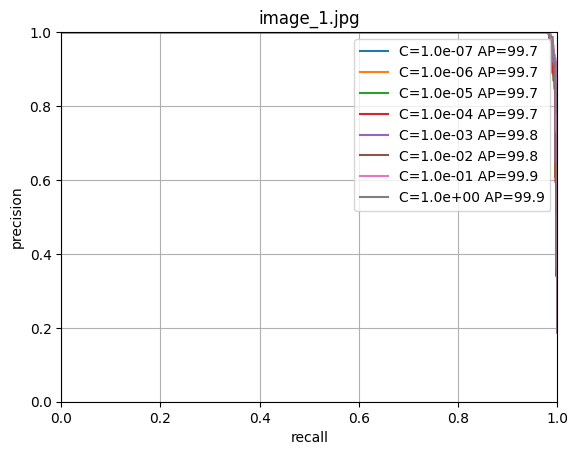

validation using image_2.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


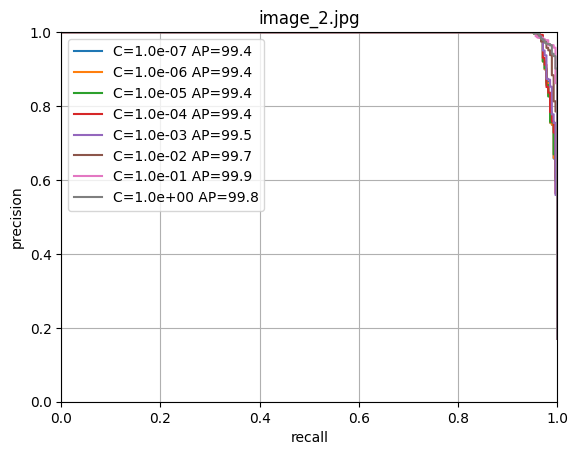

validation using image_3.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


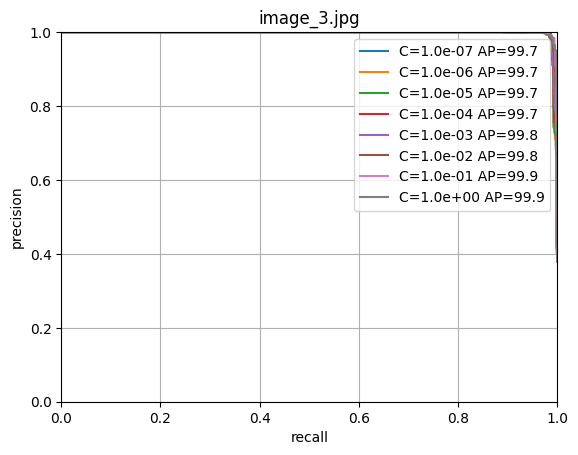

validation using image_4.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


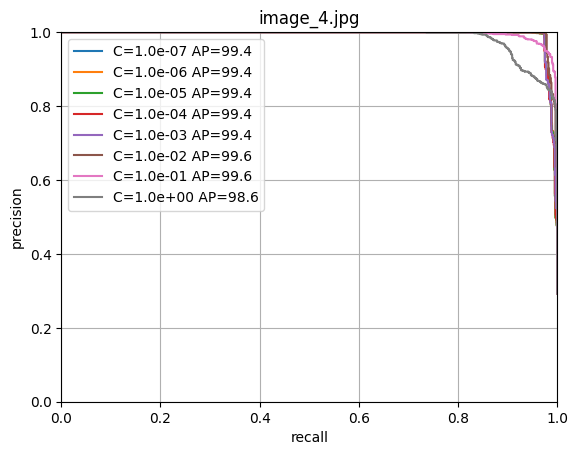

validation using image_5.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


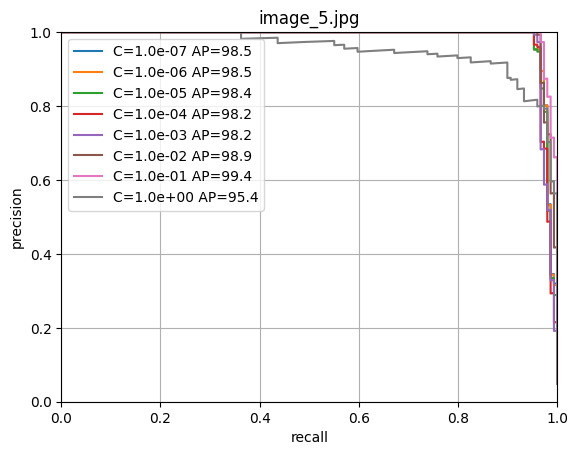

validation using image_6.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


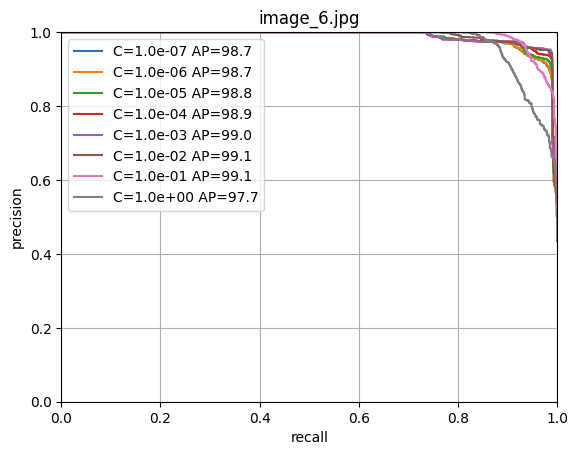

validation using image_7.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


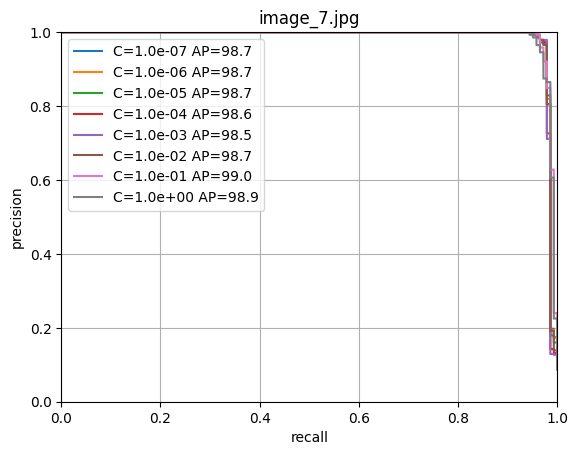

validation using image_8.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


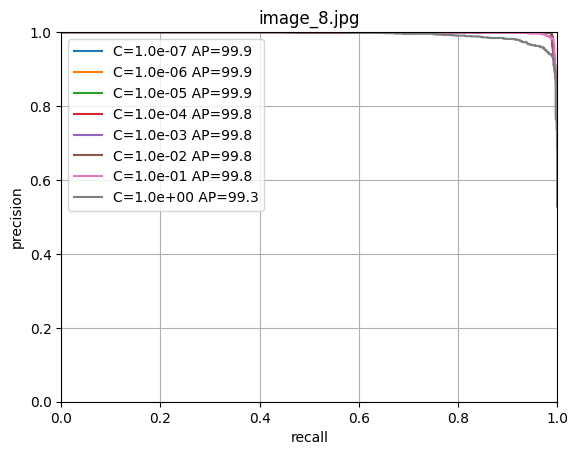

validation using image_9.jpg
training logistic regression with C=1e-07
training logistic regression with C=1e-06
training logistic regression with C=1e-05
training logistic regression with C=0.0001
training logistic regression with C=0.001
training logistic regression with C=0.01
training logistic regression with C=0.1
training logistic regression with C=1.0


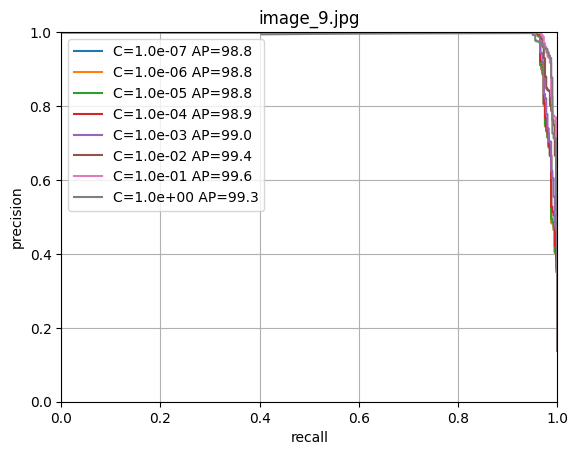

In [30]:
for i in range(n_images):
    # we use leave-one-out so train will be all but image i, val will be image i
    print(f'validation using image_{i+1}.jpg')
    train_selection = image_index != float(i) # extract image except for image i
    fold_x = xs[train_selection].numpy()
    fold_y = (ys[train_selection] > 0).long().numpy() # classifier expects that ys is integer label
    val_x = xs[~train_selection].numpy()
    val_y = (ys[~train_selection] > 0).long().numpy()

    plt.figure()
    for j, c in enumerate(cs):
        print(f'training logistic regression with C={c}')
        clf = LogisticRegression(random_state=0, C=c, max_iter=100000).fit(fold_x, fold_y)
        output = clf.predict_proba(val_x) # get probability 
        precision, recall, thresholds = precision_recall_curve(val_y, output[:, 1])
        s = average_precision_score(val_y, output[:, 1])
        scores[i, j] = s
        plt.plot(recall, precision, label='C={:.1e} AP={:.1f}'.format(c, s*100))

    plt.grid()
    plt.xlabel('recall')
    plt.title(f'image_{i+1}.jpg')
    plt.ylabel('precision')
    plt.axis([0, 1, 0, 1])
    plt.legend()
    plt.show()

# Retraining with the optimal regularization

In [33]:
clf = LogisticRegression(random_state=0, C=0.1, max_iter=100000, verbose=2).fit(xs.numpy(), (ys > 0).long().numpy())

# Test image ind inference

In [34]:
test_image_url = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/test_image.jpg"

def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")

In [84]:
test_image_path = '../dataset/coffe.jpg'

def load_image_from_local(path: str) -> Image:
    return Image.open(path).convert('RGB')

In [85]:
#test_image = load_image_from_url(test_image_url)
test_image = load_image_from_local(test_image_path)
test_image_resized = resize_transform(test_image)
test_image_normalized = TF.normalize(test_image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

mask image w: 4624, h: 3472
num of patch h: 48, w: 63


In [86]:
test_image.show()

In [87]:
with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = model.get_intermediate_layers(test_image_normalized.unsqueeze(0).cuda(), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

In [88]:
num_h_patches, num_w_pathes = [int(d / PATCH_SIZE) for d in test_image_resized.shape[1:]]
print(num_h_patches, num_w_pathes)

48 63


In [89]:
fg_score = clf.predict_proba(x) # [:, 0] class0 = bg proba, [:, 1] class1 = fg proba
fg_score = fg_score[:, 1].reshape(num_h_patches, num_w_pathes)
fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))

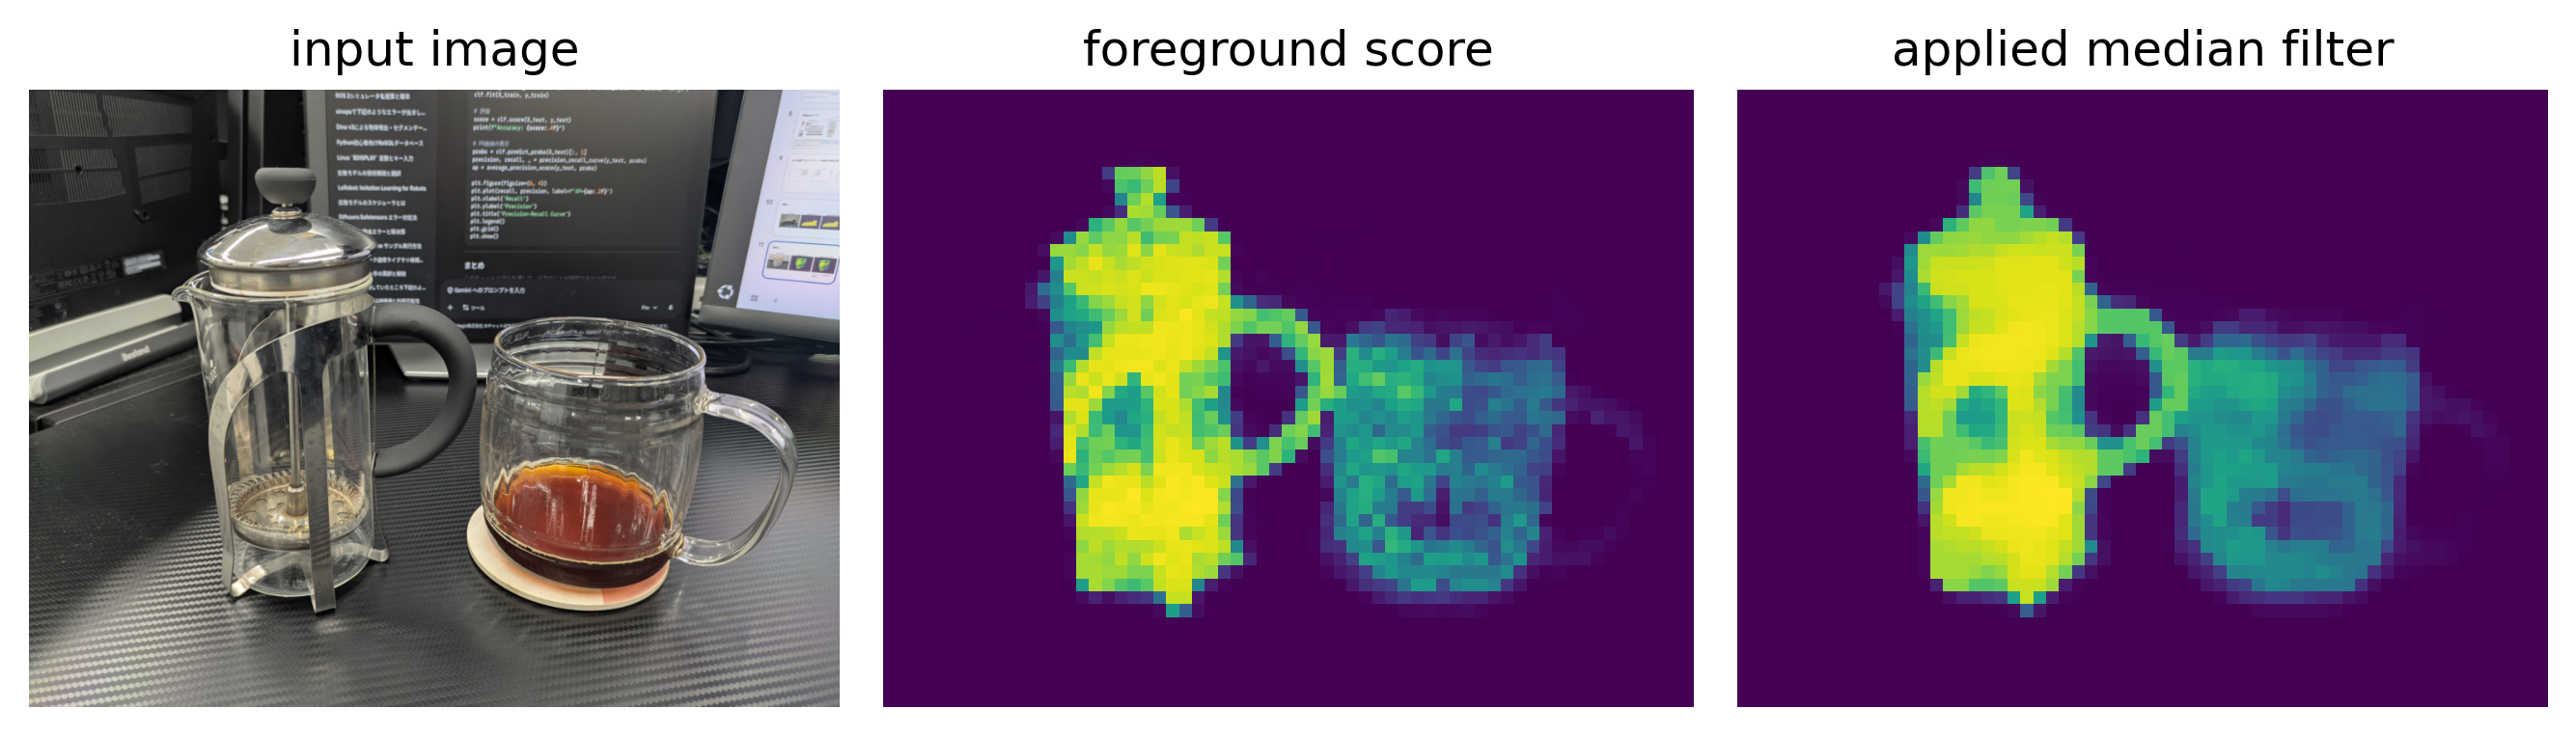

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=300)

# 1 input image
# [C, H, W] -> [H, W, C]
axes[0].imshow(test_image_resized.permute(1, 2, 0).cpu())
axes[0].set_title('input image')
axes[0].axis('off')

# 2 foreground score (the result of predict_proba)
axes[1].imshow(fg_score)
axes[1].set_title('foreground score')
axes[1].axis('off')

# 3 median filter
axes[2].imshow(fg_score_mf)
axes[2].set_title('applied median filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [65]:
feats[0].shape

torch.Size([1, 1024, 48, 64])